<a href="https://colab.research.google.com/github/liminalvoid/nlp/blob/main/sem_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import math
import random
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
import requests

url = "https://www.gutenberg.org/files/1342/1342-0.txt"
text = requests.get(url).text

print(text[:2000])
print("Total characters:", len(text))

*** START OF THE PROJECT GUTENBERG EBOOK 1342 ***




                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKIN HOUSE
                                   ]

                            [Illustration:

               _Reading Jane’s Letters._      _Chap 34._
                                   ]




                                PRIDE.
                                  and
                               PREJUDICE

                                  by
                             Jane Austen,

                           with a Preface by
                           George Saintsbury
                                  and
                           Illustrations by
                             Hugh Thomson

                         [Illustration: 1894]

                       Ruskin       156. Charing

In [ ]:
def strip_gutenberg_header_footer(text: str) -> str:
    start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

    start_idx = text.find(start_marker)
    end_idx = text.find(end_marker)

    if start_idx != -1:
        text = text[start_idx:]
        first_newline = text.find("\n")
        text = text[first_newline + 1:]
    if end_idx != -1:
        text = text[:end_idx]
    return text

text = strip_gutenberg_header_footer(text)
text = text.lower()

# Простая токенизация: слова + знаки препинания
tokens = re.findall(r"\w+|[^\w\s]", text, re.UNICODE)

print(tokens[:50])
print("Number of tokens:", len(tokens))
print("Number of unique raw tokens:", len(set(tokens)))

['[', 'illustration', ':', 'george', 'allen', 'publisher', '156', 'charing', 'cross', 'road', 'london', 'ruskin', 'house', ']', '[', 'illustration', ':', '_reading', 'jane', '’', 's', 'letters', '.', '_', '_chap', '34', '.', '_', ']', 'pride', '.', 'and', 'prejudice', 'by', 'jane', 'austen', ',', 'with', 'a', 'preface', 'by', 'george', 'saintsbury', 'and', 'illustrations', 'by', 'hugh', 'thomson', '[', 'illustration']
Number of tokens: 154414
Number of unique raw tokens: 7052


In [ ]:
MAX_TOKENS = 500_000     # можно увеличить до 100_000 или больше
MAX_VOCAB = 5000

tokens = tokens[:MAX_TOKENS]
print("Using tokens:", len(tokens))

counter = Counter(tokens)
most_common = counter.most_common(MAX_VOCAB - 2)  # reserving <pad>, <unk>

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]

def encode_token(tok):
    return stoi.get(tok, UNK_ID)

ids = [encode_token(tok) for tok in tokens]

print("Vocab size:", len(itos))
print("First 30 ids:", ids[:30])

Using tokens: 154414
Vocab size: 5000
First 30 ids: [112, 125, 84, 359, 429, 4219, 2572, 3184, 1700, 860, 300, 3185, 165, 113, 112, 125, 84, 4220, 79, 35, 39, 821, 3, 316, 4221, 4222, 3, 316, 113, 317]


In [ ]:
SEQ_LEN = 30
TRAIN_FRAC = 0.9
BATCH_SIZE = 32

class LanguageModelingDataset(Dataset):
    def __init__(self, ids, seq_len):
        self.ids = ids
        self.seq_len = seq_len

    def __len__(self):
        return len(self.ids) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx: idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx + 1: idx + self.seq_len + 1], dtype=torch.long)
        return x, y

split_idx = int(len(ids) * TRAIN_FRAC)
train_ids = ids[:split_idx]
test_ids = ids[split_idx:]

train_dataset = LanguageModelingDataset(train_ids, SEQ_LEN)
test_dataset = LanguageModelingDataset(test_ids, SEQ_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print("Train tokens:", len(train_ids))
print("Test tokens:", len(test_ids))
print("Train examples:", len(train_dataset))
print("Test examples:", len(test_dataset))

xb, yb = next(iter(train_loader))
print("xb shape:", xb.shape)
print("yb shape:", yb.shape)

Train tokens: 138972
Test tokens: 15442
Train examples: 138942
Test examples: 15412
xb shape: torch.Size([32, 30])
yb shape: torch.Size([32, 30])


## Shapes in the model

- input ids: `(batch_size, seq_len)`
- embeddings: `(batch_size, seq_len, emb_dim)`
- RNN hidden states: `(batch_size, seq_len, hidden_dim)`
- output logits: `(batch_size, seq_len, vocab_size)`

На каждом шаге модель предсказывает распределение по всему словарю.

In [ ]:
class WordRNN(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, h0=None):
        # x: (B, L)
        x = self.emb(x)          # (B, L, E)
        h, h_n = self.rnn(x, h0) # h: (B, L, H)
        logits = self.out(h)     # (B, L, V)
        return logits, h_n

In [ ]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordRNN(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordRNN(
  (emb): Embedding(5000, 16)
  (rnn): RNN(16, 16, batch_first=True)
  (out): Linear(in_features=16, out_features=5000, bias=True)
)

In [ ]:
VOCAB_SIZE = len(itos)
EMB_DIM = 16
HIDDEN_DIM = 16

model = WordLSTM(VOCAB_SIZE, EMB_DIM, HIDDEN_DIM).to(device)
model

WordLSTM(
  (emb): Embedding(5000, 16)
  (rnn): LSTM(16, 16, batch_first=True)
  (out): Linear(in_features=16, out_features=5000, bias=True)
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
xb, yb = next(iter(loader))
xb = xb.to(device)
yb = yb.to(device)

logits, h_n = model(xb)

print("logits shape:", logits.shape)  # (B, L, V)
#print("h_n shape:", h_n.shape)        # (1, B, H)

loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
print("loss:", float(loss))

NameError: name 'loader' is not defined

In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, vocab_size):
    model.eval()
    total_loss = 0.0
    total_batches = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))

        total_loss += loss.item()
        total_batches += 1

    mean_loss = total_loss / total_batches
    ppl = math.exp(mean_loss)
    return mean_loss, ppl


EPOCHS = 10

train_losses = []
test_losses = []
train_ppls = []
test_ppls = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        logits, _ = model(xb)
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), yb.reshape(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_ppl = math.exp(train_loss)

    test_loss, test_ppl = evaluate(model, test_loader, criterion, device, VOCAB_SIZE)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_ppls.append(train_ppl)
    test_ppls.append(test_ppl)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train loss = {train_loss:.4f} | train ppl = {train_ppl:.2f} | "
        f"test loss = {test_loss:.4f} | test ppl = {test_ppl:.2f}"
    )

Epoch 1/10 | train loss = 6.4925 | train ppl = 660.19 | test loss = 5.9639 | test ppl = 389.11
Epoch 2/10 | train loss = 5.9282 | train ppl = 375.48 | test loss = 5.8590 | test ppl = 350.38
Epoch 3/10 | train loss = 5.8024 | train ppl = 331.08 | test loss = 5.7257 | test ppl = 306.64
Epoch 4/10 | train loss = 5.6457 | train ppl = 283.08 | test loss = 5.5790 | test ppl = 264.82
Epoch 5/10 | train loss = 5.4808 | train ppl = 240.04 | test loss = 5.4407 | test ppl = 230.60
Epoch 6/10 | train loss = 5.3391 | train ppl = 208.32 | test loss = 5.3325 | test ppl = 206.96
Epoch 7/10 | train loss = 5.2187 | train ppl = 184.69 | test loss = 5.2454 | test ppl = 189.68
Epoch 8/10 | train loss = 5.1184 | train ppl = 167.07 | test loss = 5.1826 | test ppl = 178.14
Epoch 9/10 | train loss = 5.0391 | train ppl = 154.33 | test loss = 5.1314 | test ppl = 169.25
Epoch 10/10 | train loss = 4.9715 | train ppl = 144.24 | test loss = 5.0893 | test ppl = 162.28


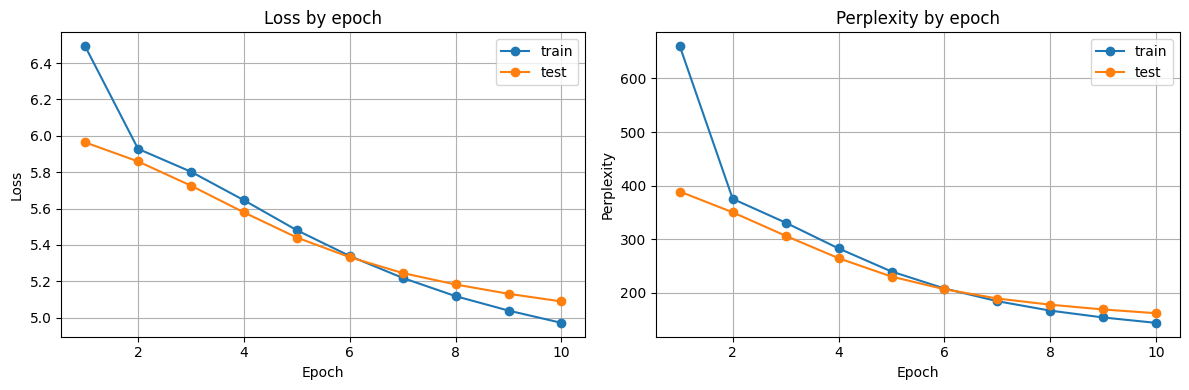

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker="o", label="train")
axes[0].plot(range(1, len(test_losses) + 1), test_losses, marker="o", label="test")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss by epoch")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, len(train_ppls) + 1), train_ppls, marker="o", label="train")
axes[1].plot(range(1, len(test_ppls) + 1), test_ppls, marker="o", label="test")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Perplexity")
axes[1].set_title("Perplexity by epoch")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
def decode_ids(id_list):
    return " ".join(itos[i] for i in id_list)

def sample_from_logits(logits, method="greedy", temperature=1.0, top_k=None):
    """
    logits: tensor of shape (V,)
    """
    logits = logits.detach().cpu()

    if method == "greedy":
        return int(torch.argmax(logits).item())

    # temperature
    logits = logits / temperature

    # top-k
    if top_k is not None:
        values, indices = torch.topk(logits, k=min(top_k, logits.shape[0]))
        probs = torch.softmax(values, dim=0)
        chosen = torch.multinomial(probs, num_samples=1).item()
        return int(indices[chosen].item())

    # plain sampling
    probs = torch.softmax(logits, dim=0)
    return int(torch.multinomial(probs, num_samples=1).item())

In [ ]:
@torch.no_grad()
def generate_text(
    model,
    prompt,
    max_new_tokens=30,
    method="greedy",
    temperature=1.0,
    top_k=None
):
    model.eval()

    prompt_tokens = re.findall(r"\w+|[^\w\s]", prompt.lower(), re.UNICODE)
    if len(prompt_tokens) == 0:
        raise ValueError("Prompt is empty after tokenization.")

    input_ids = [stoi.get(tok, UNK_ID) for tok in prompt_tokens]
    generated = input_ids[:]

    # Сначала прогоняем весь prompt, чтобы получить состояние
    x = torch.tensor([generated], dtype=torch.long, device=device)
    logits, h = model(x)

    # Последний логит соответствует предсказанию после последнего токена prompt
    next_logits = logits[0, -1]

    for _ in range(max_new_tokens):
        next_id = sample_from_logits(
            next_logits,
            method=method,
            temperature=temperature,
            top_k=top_k
        )
        generated.append(next_id)

        # Следующий шаг: подаём только последний токен и продолжаем с тем же hidden state
        x_next = torch.tensor([[next_id]], dtype=torch.long, device=device)
        logits, h = model(x_next, h)
        next_logits = logits[0, -1]

    return decode_ids(generated)

In [ ]:
prompt = "it is a truth"
print(generate_text(model, prompt, max_new_tokens=40, method="greedy"))

it is a truth , and i am , and i am , and i am , and i am , and i am , and i am , and i am , and i am , and i am , and i am


In [ ]:
prompt = "she was not"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

she was not rose . darcy . but maria ; mrs . gardiner is being stupid to <unk> , did in your behaviour . he was having affection , could rather written , she to say it of forster , and . his


In [ ]:
prompt = "she likes apples"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling"))

she likes <unk> if he was private signify so affection about , that ” “ when her sermons . the neighbourhood of ill mr . down he was entering its children , seated extreme to head there could is interrupt pemberley to find


In [ ]:
prompt = "elizabeth was"
print(generate_text(model, prompt, max_new_tokens=40, method="sampling", top_k=10))

elizabeth was to been him on him . they was not a <unk> to a very <unk> of this <unk> , and <unk> to be the dear <unk> , for her - - - room of the whole of <unk> to <unk>


## Вопросы для анализа

1. Как меняется loss по эпохам?
2. Насколько осмысленным становится текст после обучения?
3. Чем greedy decoding отличается от sampling?
4. Как влияет temperature?
5. Что меняется при top-k?
6. Какие типичные ошибки делает модель?
   - повторы
   - обрыв фраз
   - неграмматичные продолжения
   - слишком короткая память

In [ ]:
class WordLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, state=None):
        x = self.emb(x)
        h, state = self.rnn(x, state)
        logits = self.out(h)
        return logits, state

### Задание
1. Обучите word-level RNN language model на тексте Джейн Остин.
2. Постройте график training loss.
3. Сгенерируйте тексты:
   - greedy
   - sampling
   - sampling with temperature
   - sampling with top-k
4. Сравните качество генерации.
5. (Опционально) замените RNN на LSTM и сравните результаты.